# Reachy System 2 — walkthrough notebook

| Section | Module | Role |
|--------|--------|------|
| **Setup** | — | — |
| **1 — Perception** | `reachy_system2.perception` | Pollen Vision `Perception` + SDK camera: RGB, depth-backed detections, `scene` text for the LLM. |
| **2 — Reasoning** | `reachy_system2.reasoning` | OpenAI vision: plan JSON (`generate_plan`) using **scene + gripper TCP (`robot_context`) + RGB**; verification later. |
| **3 — Executor** | `reachy_system2.executor` | Parse actions, **safe workspace** checks, dispatch to `reachy2_sdk` (`wait=True` by default). |
| **4 — Verification** | `reachy_system2.reasoning` | Multimodal **verify** with before/after images. |
| **5 — Orchestration** | `reachy_system2.main` | Optional `run_closed_loop` (creates its **own** `System2Perception` — stop the walkthrough instance first). |

<div style="text-align: center">

<img src="docs/system2_architecture.png" alt="" style="max-width: 100%; width: 1100px;" />

</div>


## Setup 

- Ensures the repo root is on `sys.path` so `import reachy_system2` works from any kernel working directory.
- Loads **secrets and defaults** from `.env`

In [1]:
from pathlib import Path
import sys
import os

def find_repo_root() -> Path:
    """Walk upward until we find `.git` or a reachy_pollen-style root."""
    p = Path.cwd().resolve()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
        if (parent / "reachy_system2").is_dir() and (parent / "README.md").exists():
            return parent
    return p


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dotenv import load_dotenv

load_dotenv(REPO_ROOT / ".env")
print("REPO_ROOT =", REPO_ROOT)

REPO_ROOT = /home/nikolaraicevic/Workspace/Internal/Reachy_Pollen


## Setup — run parameters

These drive **Section 1** (labels for OWL-ViT / `Perception`) and **Section 2** (natural-language task for planning).

In [2]:
import os

HOST = os.environ.get("REACHY_HOST", "192.168.10.172")
LABELS = [s.strip() for s in os.environ.get("SYSTEM2_LABELS", "bowl,apple").split(",") if s.strip()]
TASK = os.environ.get("SYSTEM2_TASK", "Describe the scene and suggest a safe motion.")
SETTLING_S = float(os.environ.get("SETTLING_S", "0.75"))

print("HOST:", HOST)
print("LABELS:", LABELS)
print("TASK:", TASK)
print("SETTLING_S:", SETTLING_S)

HOST: 192.168.10.172
LABELS: ['tomato soup can', 'white metal bowl']
TASK: Pick up the tomato soup can and place it into the metal bowl without hitting the table.
SETTLING_S: 0.75


## Section 1 — Perception

**What this does:** connects to Reachy, builds `System2Perception`, runs `set_tracked_objects()`, and `snapshot()` to get a `PerceptionSnapshot`:
- **`rgb`**: torso camera image (fed to the LLM in Section 2)
- **`annotated_rgb`**: same frame with boxes/masks from Pollen `Perception`
- **`scene`**: text block of detected objects in **robot frame** (fed to the LLM in Section 2)
- **`objects`**: structured detections behind `scene`

In [3]:
from reachy2_sdk import ReachySDK

reachy = ReachySDK(HOST)
ic = reachy.is_connected() if callable(getattr(reachy, "is_connected", None)) else bool(reachy.is_connected)
assert ic, "Not connected — check REACHY_HOST and network."
assert reachy.cameras is not None and reachy.cameras.depth is not None, (
    "Depth camera required for Perception extrinsics (see greengrocer tutorial)."
)
print("Reachy connected; depth camera present.")

Local API version (1.0.21) is different from the robot's API version (1.0.19).
Some features may not work properly.
Please update the reachy2_core image on the robot to ensure compatibility, or downgrade your local reachy2_sdk package.
This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.



Reachy connected; depth camera present.


In [6]:
from reachy_system2.perception import System2Perception

perception = System2Perception(reachy)
perception.set_tracked_labels(LABELS)
perception.start(visualize=False)

snap = perception.snapshot(settling_s=SETTLING_S)
rgb = snap.rgb
annotated_rgb = snap.annotated_rgb
scene = snap.scene
detected_objects = snap.objects

print("--- Scene text for LLM (Section 2) ---")
print(scene)
print("RGB shape:", rgb.shape, "dtype:", rgb.dtype)
print("Detected objects (structured):", len(detected_objects))

Already connected to Reachy.
This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration. Please open a PR/issue to update `preprocessor_config.json` to use `image_processor_type` instead of `feature_extractor_type`. This warning will be removed in v4.40.


--- Scene text for LLM (Section 2) ---
DETECTED_OBJECTS (robot frame, meters; +Y = robot's left):

- tomato soup can: x=0.4621, y=-0.2054, z=-0.3280 detection_score=0.122 temporal_score=0.100
- white metal bowl: x=0.5273, y=0.1385, z=-0.3525 detection_score=0.203 temporal_score=0.300
RGB shape: (720, 1280, 3) dtype: uint8
Detected objects (structured): 2


### Section 1 — visualize detections

Shows `annotated_rgb` from the same `snapshot()` as above (boxes/masks match `scene` / `objects`). Raw `rgb` is what Section 2 sends to the LLM.

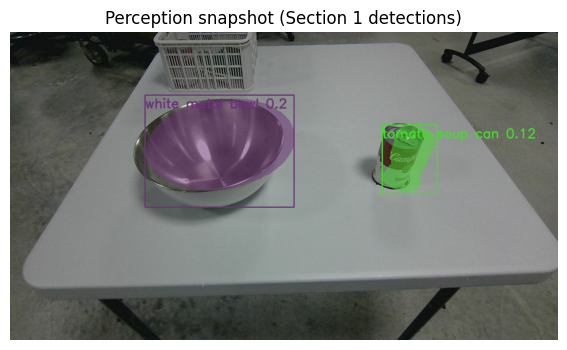

In [7]:
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 4))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title("Perception snapshot (Section 1 detections)")
    plt.show()
except Exception as e:
    print("matplotlib display skipped:", e)

## Section 2 — Reasoning (`reachy_system2.reasoning`)

**What this does:** calls OpenAI with **text + image**: PERCEPTION (`scene`), ROBOT_STATE (gripper TCP from `forward_kinematics()` — same idea as `3_arm_and_gripper.ipynb`), RGB (`rgb`), plus collision-aware rules in the system prompt. Returns a **JSON plan** (`subtasks` with structured `actions`).

### Quick OpenAI check

The next cell is a tiny `chat.completions` call (same stack as `ReasoningClient`). Ensure `OPENAI_API_KEY` is set in `.env` (loaded in Setup), then run it before the planning cells.


In [ ]:
import os

from openai import OpenAI

_base = (os.environ.get("OPENAI_BASE_URL") or "").strip() or None
client = OpenAI(base_url=_base) if _base else OpenAI()

response = client.chat.completions.create(
    model=os.environ.get("OPENAI_MODEL", "gpt-4o"),
    messages=[
        {"role": "user", "content": "Write a one-sentence bedtime story about a unicorn."}
    ],
    max_tokens=80,
)
print(response.choices[0].message.content)


In [ ]:
import json

from reachy_system2.reasoning import ReasoningClient
from reachy_system2.robot_context import format_end_effector_context_for_llm

reasoning = ReasoningClient()
ee_context = format_end_effector_context_for_llm(reachy)
plan = reasoning.generate_plan(TASK, scene, rgb, tracked_labels=LABELS, robot_context=ee_context)
print(json.dumps(plan, indent=2)[:8000])

## Section 3 — Executor

**What this does:** `ActionExecutor` maps each JSON `action` to `reachy2_sdk` calls. Before Cartesian `goto`, translations are checked against the **safe workspace** box from `.env` / `config.py`.

Below: **validate** the first subtask, then **`dry_run=True`** so no real motion is sent (safe smoke test).

In [ ]:
from reachy_system2.executor import ActionExecutor

executor = ActionExecutor(reachy)
sub0 = plan["subtasks"][0]

v = executor.validate_subtask_bounds(sub0)
print("validate_subtask_bounds:", v)

r = executor.run_subtask(sub0, wait=True, dry_run=False)
print("run_subtask (dry_run=True):", r)

## Section 4 — Verification (`verify_execution`)

**What this does:** after a subtask (here we only did a **dry_run**, so the scene may be unchanged), grab a **fresh snapshot**, then ask the model whether the subtask succeeded (`OK` / `FAILED`) and optionally return a **correction** JSON.

In the full loop (`run_closed_loop`), this runs after **real** motion with `rgb_before` / `rgb_after`.

In [ ]:
import json

rgb_before = rgb
snap2 = perception.snapshot(settling_s=SETTLING_S)
rgb2, scene2 = snap2.rgb, snap2.scene

ver = reasoning.verify_execution(
    goal=TASK,
    subtask_description=sub0.get("description", ""),
    scene_after=scene2,
    rgb_after=rgb2,
    rgb_before=rgb_before,
)
print(json.dumps(ver, indent=2))

## Section 5 — Full closed loop 

**What this does:** wires **Perception → plan → validate → execute → verify** (and OOB replan / corrections) in one call. It instantiates a **new** `System2Perception`, so you must **`perception.stop()`** on the walkthrough instance first to avoid two trackers on the same robot.

Before planning, it **retries snapshots** until tracked objects appear (each `SYSTEM2_LABEL` matched loosely to a detection name), up to **`SYSTEM2_SNAPSHOT_MAX_ATTEMPTS`** with **`PERCEPTION_RETRY_SETTLING_S`** between tries. 

In [8]:
from reachy_system2.main import run_closed_loop

# Required before uncommenting run_closed_loop: release the Perception thread started in Section 1.
perception.stop()

# With confirm_steps=True, after each subtask JSON you must type y + Enter (notebook input box).
# Tuning (optional): perception_max_attempts=30, require_every_tracked_label=False
# Defaults: SYSTEM2_SNAPSHOT_MAX_ATTEMPTS, SYSTEM2_REQUIRE_ALL_LABELS in .env
run_closed_loop(
    reachy=reachy,
    task=TASK,
    labels=LABELS,
    settling_s=SETTLING_S,
    confirm_steps=True,
    dry_run=False,
    log_runs=True,
    robot_host=HOST,
)

print("Walkthrough cells finished.")

Already connected to Reachy.
This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration. Please open a PR/issue to update `preprocessor_config.json` to use `image_processor_type` instead of `feature_extractor_type`. This warning will be removed in v4.40.



--- Subtask 1/4 ---
{
  "description": "Approach the tomato soup can.",
  "actions": [
    {
      "op": "r_arm_goto_pose",
      "xyz": [
        0.4438,
        -0.2296,
        -0.2
      ],
      "rpy_deg": [
        0,
        0,
        0
      ],
      "duration": 2.0
    }
  ]
}

>>> Waiting for confirmation: type y + Enter to run this on the robot, or n + Enter to abort. <<<

--- Subtask 2/4 ---
{
  "description": "Grasp the tomato soup can.",
  "actions": [
    {
      "op": "r_arm_translate",
      "x": 0,
      "y": 0,
      "z": -0.126,
      "frame": "robot"
    },
    {
      "op": "r_gripper_goto",
      "position": 0,
      "duration": 1.0
    }
  ]
}

>>> Waiting for confirmation: type y + Enter to run this on the robot, or n + Enter to abort. <<<

--- Subtask 3/4 ---
{
  "description": "Lift the tomato soup can.",
  "actions": [
    {
      "op": "r_arm_translate",
      "x": 0,
      "y": 0,
      "z": 0.15,
      "frame": "robot"
    }
  ]
}

>>> Waiting for confi

This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.

